In [1]:
import numpy as np
import random
from multiprocessing import Pool
import pandas as pd
from scipy.interpolate import interp1d
from scipy.special import gamma
from scipy.stats import binom

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.font_manager as font_manager
font_manager.fontManager.addfont('/home/vvelan/DarkLim/examples/styles/Times_New_Roman.ttf')

mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['font.serif'] = 'Times New Roman'
plt.rcParams['mathtext.fontset'] = 'stix'
plt.style.use('/home/vvelan/DarkLim/examples/styles/Style.mplstyle')

import sys
sys.path.insert(0, 'ExistingLimits/')
#import MichaelLimits as ML

import darklim
sys.path.insert(0, '/home/vvelan/DarkELF/')
import darkelf

import qetpy
import detprocess

%matplotlib inline


Expected mean: 1.00, Binomial Variance: 0.60, Extra Variance: 0.04
Observed mean: 1.00, Variance: 0.64


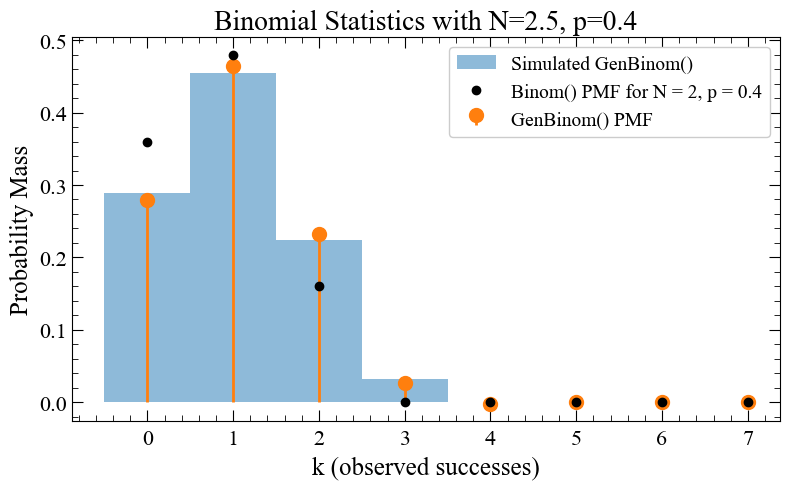

In [2]:

def generalized_binomial_pmf(k, N, p):
    """Generalized binomial PMF using the Gamma function."""
    coeff = gamma(N + 1) / (gamma(k + 1) * gamma(N - k + 1))
    return coeff * (p ** k) * ((1 - p) ** (N - k))

def generalized_binomial_sample(N, p, size=1):
    """
    Generate random samples from a generalized binomial distribution
    with real-valued N by interpreting it as the sum of Bernoulli(p)
    trials from N independent sources, where a fraction of one trial
    is included probabilistically.
    """
    samples = []
    N_int = int(np.floor(N))
    N_frac = N - N_int
    
    for _ in range(size):
        # Integer part: standard binomial sample
        count = np.random.binomial(N_int, p)
        
        # Fractional part: simulate one extra trial with probability N_frac
        if random.random() < N_frac:
            if random.random() < p:
                count += 1
                
        samples.append(count)
        
    if size == 1:
        return samples[0]
    else:
        return np.array(samples)

# Parameters
N_nonint = 2.5  # Non-integer N
p = 0.4
k_vals = np.arange(0, int(np.ceil(N_nonint)) + 5)

# Compute PMF for generalized binomial distribution
pmf_vals = np.array([generalized_binomial_pmf(k, N_nonint, p) for k in k_vals])
pmf_vals /= np.sum(pmf_vals) # Normalize (since it doesn't sum to 1 for non-integer N)

# Simulate 10,000 samples
simulated_samples = generalized_binomial_sample(N_nonint, p, size=300_000)

# Histogram
fig, ax = plt.subplots(1,1, figsize=(8, 5))
ax.hist(simulated_samples, bins=np.arange(simulated_samples.min(), simulated_samples.max() + 2) - 0.5, 
         density=True, alpha=0.5, label=f'Simulated GenBinom()', color='C0')

# Plot analytical PMF for comparison
ax.stem(k_vals, pmf_vals, basefmt=" ", linefmt='C1-', markerfmt='C1o', label='GenBinom() PMF')

# Plot the standard binomial PMF for comparison
ax.plot(k_vals, binom.pmf(k_vals, int(np.floor(N_nonint)), p), 'ko', ms=6, label=f'Binom() PMF for N = {np.floor(N_nonint):.0f}, p = {p}')

ax.set_title(f"Binomial Statistics with N={N_nonint}, p={p}")
ax.set_xlabel("k (observed successes)")
ax.set_ylabel("Probability Mass")
ax.legend(framealpha=1., fontsize=14)

fig.tight_layout()
fig.show()

# Print some statistics
decimal = N_nonint - int(np.floor(N_nonint))
print(f'Expected mean: {N_nonint * p:.2f}, Binomial Variance: {N_nonint * p * (1 - p):.2f}, Extra Variance: {decimal * (1 - decimal) * p * p:.2f}')
print(f'Observed mean: {np.mean(simulated_samples):.2f}, Variance: {np.var(simulated_samples):.2f}')


In [3]:
def Lindhard(E_keV):

    Y = np.zeros(2)
    for i, (element, Z, A) in enumerate(zip(['Ga', 'As'], [31., 33.], [69.7, 74.9])):

        eta = 11.5 * E_keV * Z**(-7/3)
        k = 0.133 * Z**(2/3) * A**(-1/2)
        G = 3 * eta**(0.15) + 0.7 * eta**(0.6) + eta
        Y[i] = (k * G) / (1 + k * G)

    return np.mean(Y)


### ER Signals

Expect mean number of pairs: 222.222, variance: 26.667. This corresponds to N = 252.525, p = 0.880.
Observed mean number of electron-hole pairs: 222.213, variance 26.632
Number of Photodetector Hits: mu = 6.659, sigma = 6.461
Number of GaAs eh pairs: mu = 88.892, sigma = 57.724

Means: 5.994 eV in Photodetector, 880.011 eV in GaAs


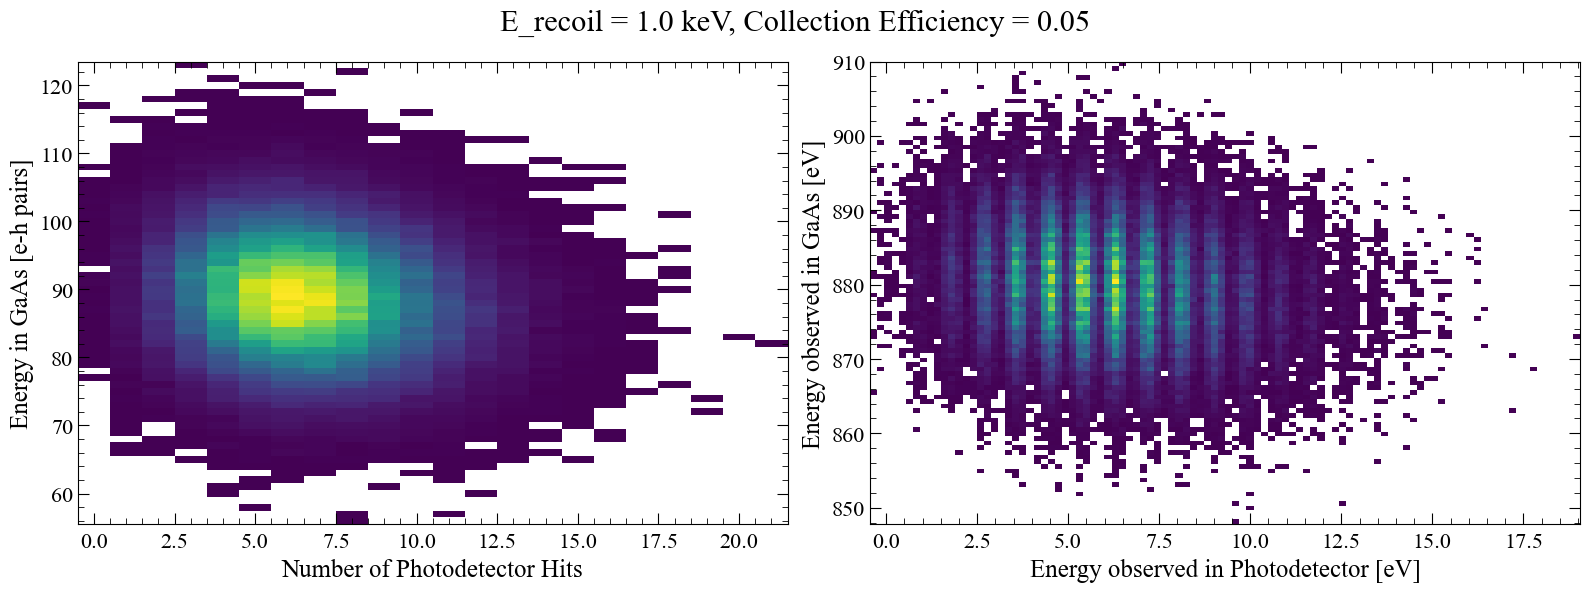

In [4]:
GaAs_band_gap = 1.5e-3  # Band gap energy in keV
GaAs_QE = 0.6 # Quantum efficiency of GaAs photodetector
GaAs_Fano = 0.12        # Fano factor
GaAs_gamma_energy = 0.9e-3  # Energy of recombined e-h photons in keV

def calculate_electron_hole_pairs(E_recoil, verbose=False):
    """
    Calculate the number of electron-hole pairs generated based on the recoil energy.

    Parameters:
        E_recoil (float): The recoil energy in keV.

    Returns:
        int: The number of electron-hole pairs generated.
    """
    # Constants

    if E_recoil < GaAs_band_gap:
        # If energy is less than the band gap, no electron-hole pairs are generated
        return 0
    elif GaAs_band_gap <= E_recoil <= 3 * GaAs_band_gap:
        # If energy is between the band gap and 3 times the band gap, return 1
        return 1
    else:
        # If energy is greater than 3 times the band gap, calculate the expected number of pairs
        N = E_recoil / (3 * GaAs_band_gap) / (1 - GaAs_Fano)
        p = 1 - GaAs_Fano
        if verbose:
            print(f'Expect mean number of pairs: {N*p:.03f}, variance: {N*p*(1-p):.03f}. This corresponds to N = {N:.03f}, p = {p:.03f}.')
        return generalized_binomial_sample(N, p)

collection_efficiency = 0.05 # v0 = 0.05, v1 = 0.21, v2 = 0.34
E_recoil = 1.
E_res = 0.18e-3  # Resolution in keV
GaAs_res_ratio = np.sqrt(2)  # Resolution ratio for GaAs/Si
rng = np.random.default_rng(12345)

N_eh = np.zeros(100_000)
N_photons = np.zeros_like(N_eh)
N_photons_PD = np.zeros_like(N_eh)
N_photons_sink = np.zeros_like(N_eh)
N_eh_non_photon = np.zeros_like(N_eh)
E_PD_keV = np.zeros_like(N_eh)
E_GaAs_keV = np.zeros_like(N_eh)
E_GaAs_obs_keV = np.zeros_like(N_eh)

for i in range(len(N_eh)):
    N_eh[i] = calculate_electron_hole_pairs(E_recoil, verbose=(True if i == 0 else False))

    N_photons[i] = rng.binomial(N_eh[i], GaAs_QE)
    N_photons_PD[i] = rng.binomial(N_photons[i], collection_efficiency)
    #N_photons_sink[i] = rng.binomial(N_photons[i], 1 - collection_efficiency)
    N_photons_sink[i] = N_photons[i] - N_photons_PD[i]
    N_eh_non_photon[i] = N_eh[i] - N_photons_PD[i] - N_photons_sink[i]

    E_PD_keV[i] = rng.normal(N_photons_PD[i] * GaAs_gamma_energy, E_res)
    E_GaAs_keV[i] = E_recoil - (N_photons_PD[i] + N_photons_sink[i]) * GaAs_gamma_energy
    E_GaAs_obs_keV[i] = rng.normal(E_GaAs_keV[i], E_res * GaAs_res_ratio)
    
# Calculate the mean and variance of the number of pairs generated
print(f"Observed mean number of electron-hole pairs: {np.mean(N_eh):.3f}, variance {np.var(N_eh):.3f}")

# Plot the results in counts
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

bins_PD = np.arange(min(N_photons_PD) - 0.5, max(N_photons_PD) + 1.5, 1)
bins_GaAs = np.arange(min(N_eh_non_photon) - 0.5, max(N_eh_non_photon) + 1.5, 1)
ax[0].hist2d(N_photons_PD, N_eh_non_photon, bins=(bins_PD, bins_GaAs), cmap='viridis', cmin=1)

ax[0].set_xlabel('Number of Photodetector Hits')
ax[0].set_ylabel('Energy in GaAs [e-h pairs]')

print(f'Number of Photodetector Hits: mu = {np.mean(N_photons_PD):.3f}, sigma = {np.var(N_photons_PD):.3f}')
print(f'Number of GaAs eh pairs: mu = {np.mean(N_eh_non_photon):.3f}, sigma = {np.var(N_eh_non_photon):.3f}')

# Plot the results in energy
ax[1].hist2d(E_PD_keV*1e3, E_GaAs_obs_keV*1e3, bins=(100, 100), cmap='viridis', cmin=1)
print(f'\nMeans: {np.mean(E_PD_keV)*1e3:.3f} eV in Photodetector, {np.mean(E_GaAs_obs_keV)*1e3:.3f} eV in GaAs')

ax[1].set_xlabel('Energy observed in Photodetector [eV]')
ax[1].set_ylabel('Energy observed in GaAs [eV]')
fig.suptitle(f'E_recoil = {E_recoil} keV, Collection Efficiency = {collection_efficiency:.2f}', fontsize=22)
#fig.title('Energy Distribution in Photodetector and GaAs')

fig.tight_layout()
fig.show()

### NR Signals

Expect mean number of pairs: 38.137, variance: 4.576. This corresponds to N = 43.337, p = 0.880.
Observed mean number of electron-hole pairs: 38.129, variance 4.734
Number of Photodetector Hits: mu = 1.146, sigma = 1.116
Number of GaAs eh pairs: mu = 15.239, sigma = 9.999

Means: 1.031 eV in Photodetector, 979.399 eV in GaAs


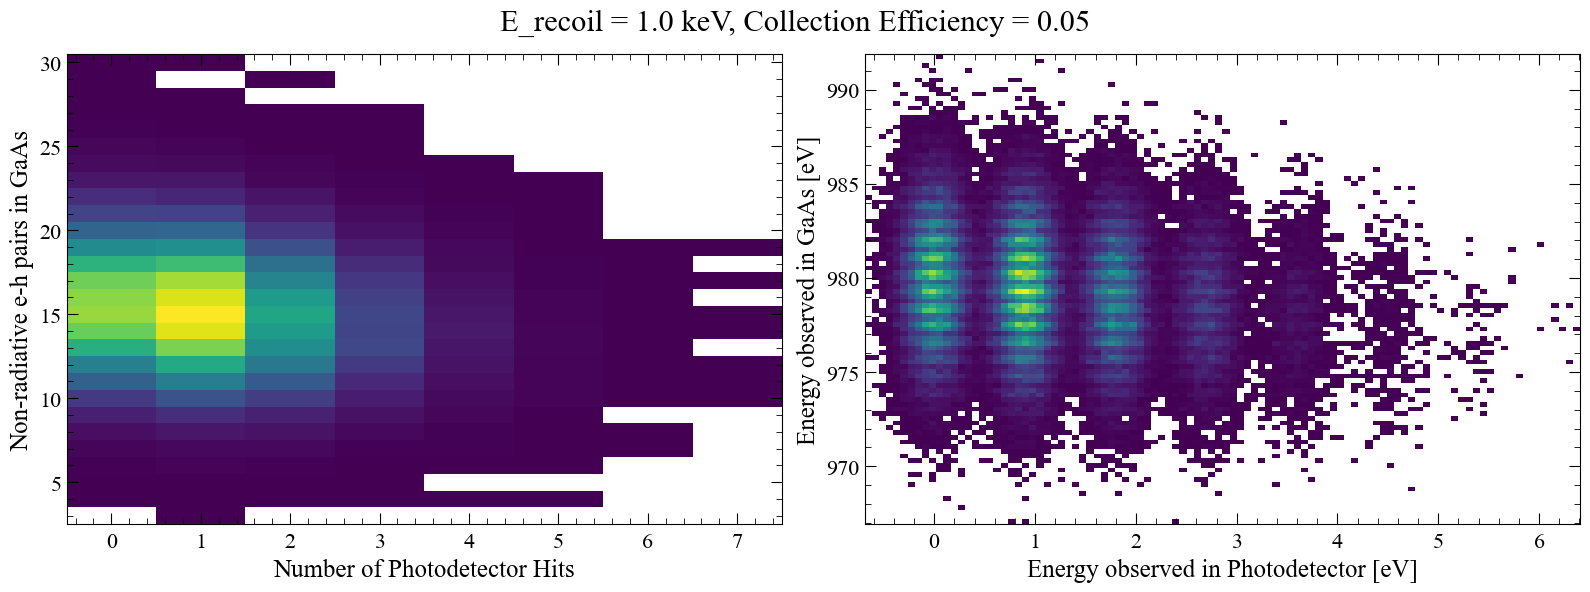

In [5]:
E_recoil_NR = 1.

N_eh = np.zeros(100_000)
N_photons = np.zeros_like(N_eh)
N_photons_PD = np.zeros_like(N_eh)
N_photons_sink = np.zeros_like(N_eh)
N_eh_non_photon = np.zeros_like(N_eh)
E_PD_keV = np.zeros_like(N_eh)
E_GaAs_keV = np.zeros_like(N_eh)
E_GaAs_obs_keV = np.zeros_like(N_eh)

for i in range(len(N_eh)):
    N_eh[i] = calculate_electron_hole_pairs(E_recoil_NR * Lindhard(E_recoil_NR), verbose=(True if i == 0 else False))

    N_photons[i] = rng.binomial(N_eh[i], GaAs_QE)
    N_photons_PD[i] = rng.binomial(N_photons[i], collection_efficiency)
    #N_photons_sink[i] = rng.binomial(N_photons[i], 1 - collection_efficiency)
    N_photons_sink[i] = N_photons[i] - N_photons_PD[i]
    N_eh_non_photon[i] = N_eh[i] - N_photons_PD[i] - N_photons_sink[i]

    E_PD_keV[i] = rng.normal(N_photons_PD[i] * GaAs_gamma_energy, E_res)
    E_GaAs_keV[i] = E_recoil_NR - (N_photons_PD[i] + N_photons_sink[i]) * GaAs_gamma_energy
    E_GaAs_obs_keV[i] = rng.normal(E_GaAs_keV[i], E_res * GaAs_res_ratio)
    
# Calculate the mean and variance of the number of pairs generated
print(f"Observed mean number of electron-hole pairs: {np.mean(N_eh):.3f}, variance {np.var(N_eh):.3f}")

# Plot the results in counts
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

bins_PD = np.arange(min(N_photons_PD) - 0.5, max(N_photons_PD) + 1.5, 1)
bins_GaAs = np.arange(min(N_eh_non_photon) - 0.5, max(N_eh_non_photon) + 1.5, 1)
ax[0].hist2d(N_photons_PD, N_eh_non_photon, bins=(bins_PD, bins_GaAs), cmap='viridis', cmin=1)

ax[0].set_xlabel('Number of Photodetector Hits')
ax[0].set_ylabel('Non-radiative e-h pairs in GaAs')

print(f'Number of Photodetector Hits: mu = {np.mean(N_photons_PD):.3f}, sigma = {np.var(N_photons_PD):.3f}')
print(f'Number of GaAs eh pairs: mu = {np.mean(N_eh_non_photon):.3f}, sigma = {np.var(N_eh_non_photon):.3f}')

# Plot the results in energy
ax[1].hist2d(E_PD_keV*1e3, E_GaAs_obs_keV*1e3, bins=(100, 100), cmap='viridis', cmin=1)
print(f'\nMeans: {np.mean(E_PD_keV)*1e3:.3f} eV in Photodetector, {np.mean(E_GaAs_obs_keV)*1e3:.3f} eV in GaAs')

ax[1].set_xlabel('Energy observed in Photodetector [eV]')
ax[1].set_ylabel('Energy observed in GaAs [eV]')
fig.suptitle(f'E_recoil = {E_recoil_NR} keV, Collection Efficiency = {collection_efficiency:.2f}', fontsize=22)
#fig.title('Energy Distribution in Photodetector and GaAs')

fig.tight_layout()
fig.show()

 .... Loading files for GaAs
Loaded GaAs_mermin.dat for epsilon in electron regime
electronic ELF taken or calculated from Y. Tu, C. Kwei and C. Tung,Angular and energy dependences of the surface excitation parameter for semiconducting iii–v compounds, Surface Science601(2007) 865.
phonon ELF taken or calculated from H.M. Lawler and E.L. Shirley, Anharmonic effects on infrared spectra of GaAs and gap:  First-principles calculations, Phys. Rev. B70(2004) 245209 and E.D. Palik, Gallium arsenide (gaas), in Handbook of Optical Constants of Solids, E.D. Palik, ed.,pp. 429–443, Elsevier (1985).
Loaded GaAs_epsphonon_data10K.dat for epsilon in phonon regime
Warning! Atomic Migdal calculation not present
Warning! Momentum dependent Zion for Migdal calculation not loaded. Using Z - number of valence electrons.
Loaded /home/vvelan/DarkELF/darkelf/../data/GaAs/Ga_pDoS.dat for partial densities of states
Loaded /home/vvelan/DarkELF/darkelf/../data/GaAs/As_pDoS.dat for partial densities of states
L

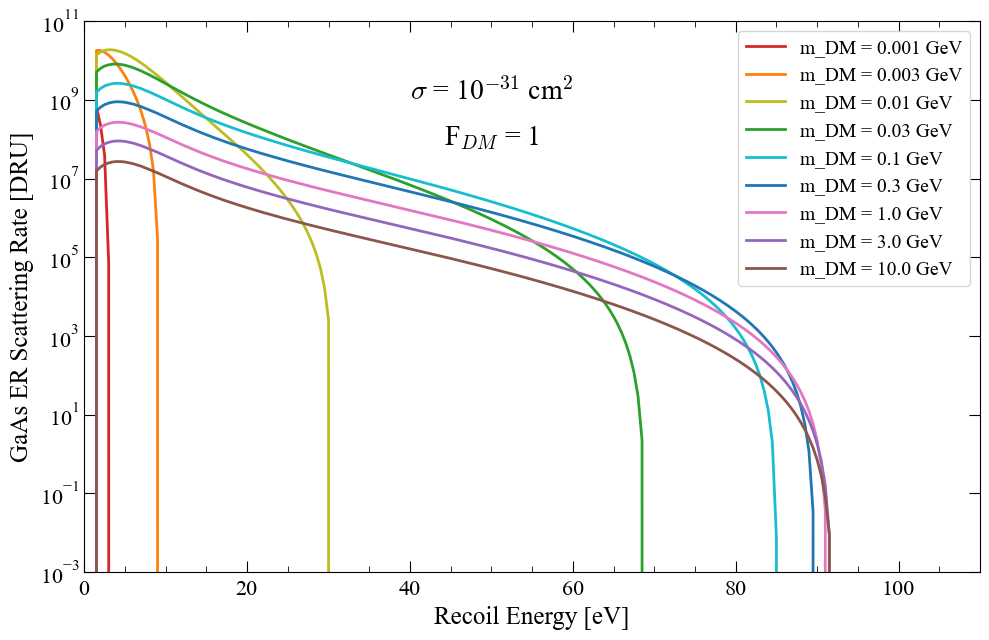

In [6]:
E_keV = np.linspace(0.5e-3, 100e-3, 200)
fig, ax = plt.subplots(figsize=(10, 6.5))

for mX, color in zip([1e6, 3e6, 1e7, 3e7, 1e8, 3e8, 1e9, 3e9, 1e10],
    ['#d62728', '#ff7f0e', '#bcbd22', '#2ca02c', '#17becf', '#1f77b4','#e377c2', '#9467bd', '#8c564b']):
    
    fun = darklim.elf.get_dRdE_lambda_GaAs_electron(mX_eV=mX, mediator='massive', sigmae=1e-31)
    dRdE = [fun(E) for E in E_keV]

    ax.plot(E_keV * 1e3, dRdE, label=f'm_DM = {mX / 1e9} GeV', color=color)

ax.text(50, 1e9, r'$\sigma$ = 10$^{-31}$ cm$^2$', fontsize=20, color='black', ha='center')
ax.text(50, 7e7, r'F$_{DM}$ = 1', fontsize=20, color='black', ha='center')

ax.set_xlabel('Recoil Energy [eV]')
ax.set_ylabel('GaAs ER Scattering Rate [DRU]')
ax.set_yscale('log')
ax.set_ylim([1e-3, 1e11])
ax.set_xlim([0, 110])
ax.legend(loc='upper right', fontsize=14)
fig.tight_layout()
fig.show()


 .... Loading files for GaAs
Loaded GaAs_mermin.dat for epsilon in electron regime
electronic ELF taken or calculated from Y. Tu, C. Kwei and C. Tung,Angular and energy dependences of the surface excitation parameter for semiconducting iii–v compounds, Surface Science601(2007) 865.
phonon ELF taken or calculated from H.M. Lawler and E.L. Shirley, Anharmonic effects on infrared spectra of GaAs and gap:  First-principles calculations, Phys. Rev. B70(2004) 245209 and E.D. Palik, Gallium arsenide (gaas), in Handbook of Optical Constants of Solids, E.D. Palik, ed.,pp. 429–443, Elsevier (1985).
Loaded GaAs_epsphonon_data10K.dat for epsilon in phonon regime
Warning! Atomic Migdal calculation not present
Warning! Momentum dependent Zion for Migdal calculation not loaded. Using Z - number of valence electrons.
Loaded /home/vvelan/DarkELF/darkelf/../data/GaAs/Ga_pDoS.dat for partial densities of states
Loaded /home/vvelan/DarkELF/darkelf/../data/GaAs/As_pDoS.dat for partial densities of states
L

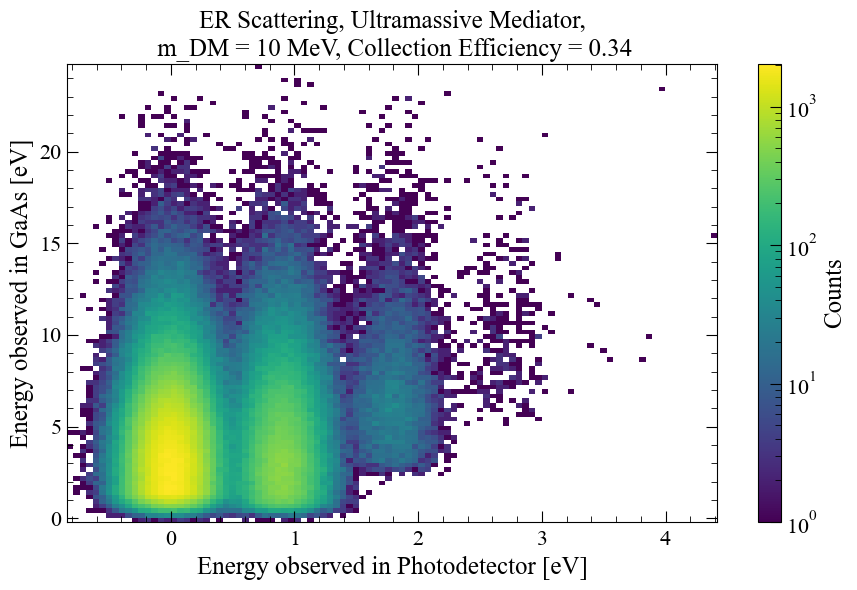

In [51]:
E_DM_keV = np.linspace(0.5e-3, 100e-3, 400)
mX_eV = 10e6
    
fun = darklim.elf.get_dRdE_lambda_GaAs_electron(mX_eV=mX_eV, mediator='massive', sigmae=1e-31)
dRdE_DM_DRU = [fun(E) for E in E_DM_keV]
pdf_DM = np.array(dRdE_DM_DRU) / np.trapz(dRdE_DM_DRU, E_DM_keV)
cdf_DM = np.cumsum(pdf_DM) * (E_DM_keV[1] - E_DM_keV[0])

########################

collection_efficiency = 0.34 # v0 = 0.05, v1 = 0.21, v2 = 0.34
E_res = 0.18e-3  # Resolution in keV
GaAs_res_ratio = np.sqrt(2)  # Resolution ratio for GaAs/Si
rng = np.random.default_rng(12345)

E_recoil = np.zeros(500_000, dtype=float)
for i in range(len(E_recoil)):
    p = rng.random()
    E_recoil[i] = np.interp(p, cdf_DM, E_DM_keV)

N_eh = np.zeros_like(E_recoil)
N_photons = np.zeros_like(N_eh)
N_photons_PD = np.zeros_like(N_eh)
N_photons_sink = np.zeros_like(N_eh)
N_eh_non_photon = np.zeros_like(N_eh)
E_PD_keV = np.zeros_like(N_eh)
E_GaAs_keV = np.zeros_like(N_eh)
E_GaAs_obs_keV = np.zeros_like(N_eh)

for i in range(len(N_eh)):
    N_eh[i] = calculate_electron_hole_pairs(E_recoil[i], verbose=(True if i == 0 else False))

    N_photons[i] = rng.binomial(N_eh[i], GaAs_QE)
    N_photons_PD[i] = rng.binomial(N_photons[i], collection_efficiency)
    #N_photons_sink[i] = rng.binomial(N_photons[i], 1 - collection_efficiency)
    N_photons_sink[i] = N_photons[i] - N_photons_PD[i]
    N_eh_non_photon[i] = N_eh[i] - N_photons_PD[i] - N_photons_sink[i]

    E_PD_keV[i] = rng.normal(N_photons_PD[i] * GaAs_gamma_energy, E_res)
    E_GaAs_keV[i] = E_recoil[i] - (N_photons_PD[i] + N_photons_sink[i]) * GaAs_gamma_energy
    E_GaAs_obs_keV[i] = rng.normal(E_GaAs_keV[i], E_res * GaAs_res_ratio)
    
# Calculate the mean and variance of the number of pairs generated
print(f"Observed mean number of electron-hole pairs: {np.mean(N_eh):.3f}, variance {np.var(N_eh):.3f}")

# Plot the results in counts
fig, ax = plt.subplots(1, 1, figsize=(9, 6))

# Plot the results in energy
h = ax.hist2d(E_PD_keV*1e3, E_GaAs_obs_keV*1e3, bins=(100, 100), norm=mpl.colors.LogNorm(), cmap='viridis', cmin=1)
fig.colorbar(h[3], ax=ax, label='Counts')

print(f'\nMeans: {np.mean(E_PD_keV)*1e3:.3f} eV in Photodetector, {np.mean(E_GaAs_obs_keV)*1e3:.3f} eV in GaAs')
print(f'Fraction of events with at least 0.9 eV in Photodetector: {np.sum(E_PD_keV > 0.9e-3) / len(E_PD_keV):.3f}')

ax.set_xlabel('Energy observed in Photodetector [eV]')
ax.set_ylabel('Energy observed in GaAs [eV]')
ax.set_title(f'ER Scattering, Ultramassive Mediator,\n m_DM = {mX_eV/1e6:.0f} MeV, Collection Efficiency = {collection_efficiency:.2f}', fontsize=18)

fig.tight_layout()
fig.show()

 .... Loading files for GaAs
Loaded GaAs_mermin.dat for epsilon in electron regime
electronic ELF taken or calculated from Y. Tu, C. Kwei and C. Tung,Angular and energy dependences of the surface excitation parameter for semiconducting iii–v compounds, Surface Science601(2007) 865.
phonon ELF taken or calculated from H.M. Lawler and E.L. Shirley, Anharmonic effects on infrared spectra of GaAs and gap:  First-principles calculations, Phys. Rev. B70(2004) 245209 and E.D. Palik, Gallium arsenide (gaas), in Handbook of Optical Constants of Solids, E.D. Palik, ed.,pp. 429–443, Elsevier (1985).
Loaded GaAs_epsphonon_data10K.dat for epsilon in phonon regime
Warning! Atomic Migdal calculation not present
Warning! Momentum dependent Zion for Migdal calculation not loaded. Using Z - number of valence electrons.
Loaded /home/vvelan/DarkELF/darkelf/../data/GaAs/Ga_pDoS.dat for partial densities of states
Loaded /home/vvelan/DarkELF/darkelf/../data/GaAs/As_pDoS.dat for partial densities of states
L

 .... Loading files for GaAs
Loaded GaAs_mermin.dat for epsilon in electron regime
electronic ELF taken or calculated from Y. Tu, C. Kwei and C. Tung,Angular and energy dependences of the surface excitation parameter for semiconducting iii–v compounds, Surface Science601(2007) 865.
phonon ELF taken or calculated from H.M. Lawler and E.L. Shirley, Anharmonic effects on infrared spectra of GaAs and gap:  First-principles calculations, Phys. Rev. B70(2004) 245209 and E.D. Palik, Gallium arsenide (gaas), in Handbook of Optical Constants of Solids, E.D. Palik, ed.,pp. 429–443, Elsevier (1985).
Loaded GaAs_epsphonon_data10K.dat for epsilon in phonon regime
Warning! Atomic Migdal calculation not present
Warning! Momentum dependent Zion for Migdal calculation not loaded. Using Z - number of valence electrons.
Loaded /home/vvelan/DarkELF/darkelf/../data/GaAs/Ga_pDoS.dat for partial densities of states
Loaded /home/vvelan/DarkELF/darkelf/../data/GaAs/As_pDoS.dat for partial densities of states
L

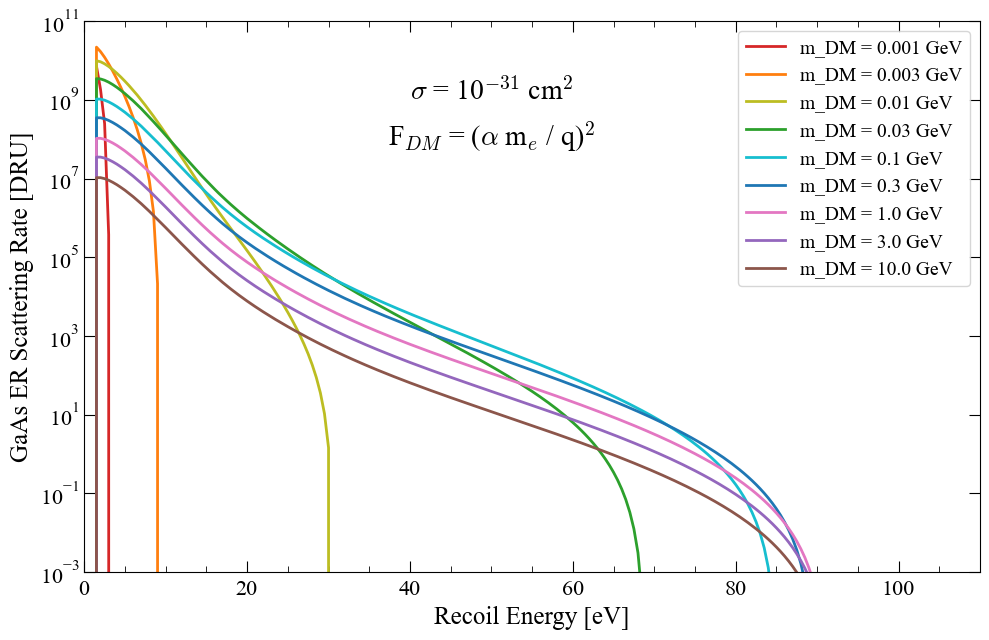

In [7]:
E_keV = np.linspace(0.5e-3, 100e-3, 200)
fig, ax = plt.subplots(figsize=(10, 6.5))

for mX, color in zip([1e6, 3e6, 1e7, 3e7, 1e8, 3e8, 1e9, 3e9, 1e10],
    ['#d62728', '#ff7f0e', '#bcbd22', '#2ca02c', '#17becf', '#1f77b4','#e377c2', '#9467bd', '#8c564b']):
    
    fun = darklim.elf.get_dRdE_lambda_GaAs_electron(mX_eV=mX, mediator='massless', sigmae=1e-31)
    dRdE = [fun(E) for E in E_keV]

    ax.plot(E_keV * 1e3, dRdE, label=f'm_DM = {mX / 1e9} GeV', color=color)

ax.text(50, 1e9, r'$\sigma$ = 10$^{-31}$ cm$^2$', fontsize=20, color='black', ha='center')
ax.text(50, 7e7, r'F$_{DM}$ = ($\alpha$ m$_e$ / q)$^2$',fontsize=20, color='black', ha='center')

ax.set_xlabel('Recoil Energy [eV]')
ax.set_ylabel('GaAs ER Scattering Rate [DRU]')
ax.set_yscale('log')
ax.set_ylim([1e-3, 1e11])
ax.set_xlim([0, 110])
ax.legend(loc='upper right', fontsize=14)
fig.tight_layout()
fig.show()


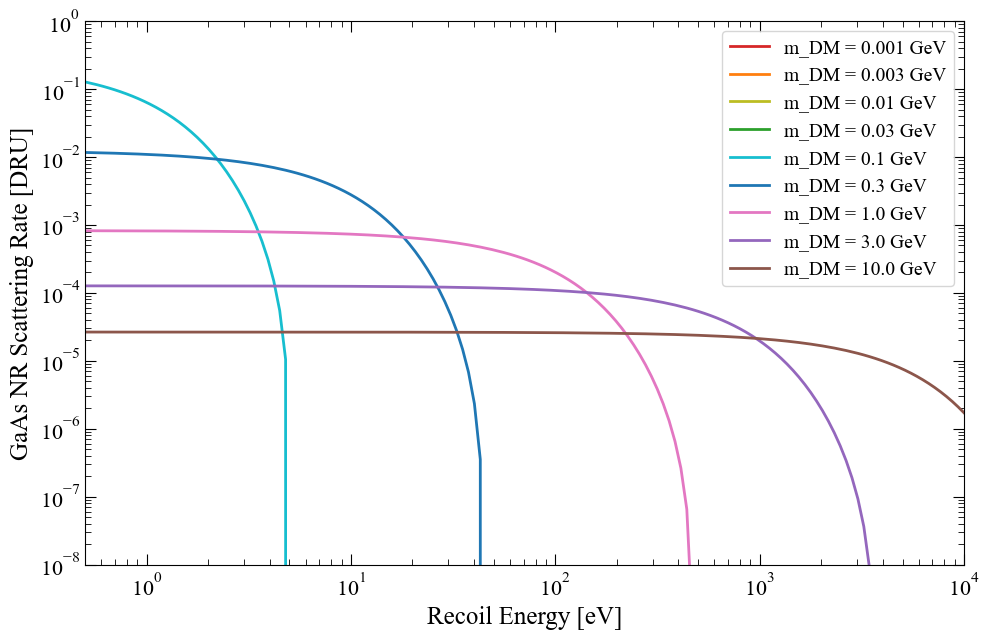

In [19]:
E_keV = np.geomspace(0.5e-3, 10, 150)
fig, ax = plt.subplots(figsize=(10, 6.5))

for i, (mX, color) in enumerate(zip([1e6, 3e6, 1e7, 3e7, 1e8, 3e8, 1e9, 3e9, 1e10],
    ['#d62728', '#ff7f0e', '#bcbd22', '#2ca02c', '#17becf', '#1f77b4','#e377c2', '#9467bd', '#8c564b'])):

    dRdE_arr = darklim.limit._limit.drde(E_keV, mX/1e9, 1e-45, 'Si')
    ax.plot(E_keV * 1e3, dRdE_arr, label=f'm_DM = {mX / 1e9} GeV', color=color)

#ax.text(50, 1e9, r'$\sigma$ = 10$^{-31}$ cm$^2$', fontsize=20, color='black', ha='center')

ax.set_xlabel('Recoil Energy [eV]')
ax.set_ylabel('GaAs NR Scattering Rate [DRU]')
ax.set_yscale('log')
ax.set_ylim([1e-8, 1e0])
ax.set_xscale('log')
ax.set_xlim([E_keV[0] * 1e3, E_keV[-1] * 1e3])
ax.legend(loc='upper right', fontsize=14)
fig.tight_layout()
fig.show()


In [ ]:
def DM_spectrum_GaAs()
E_recoil_NR = 1.

N_eh = np.zeros(100_000)
N_photons = np.zeros_like(N_eh)
N_photons_PD = np.zeros_like(N_eh)
N_photons_sink = np.zeros_like(N_eh)
N_eh_non_photon = np.zeros_like(N_eh)
E_PD_keV = np.zeros_like(N_eh)
E_GaAs_keV = np.zeros_like(N_eh)
E_GaAs_obs_keV = np.zeros_like(N_eh)

for i in range(len(N_eh)):
    N_eh[i] = calculate_electron_hole_pairs(E_recoil_NR * Lindhard(E_recoil_NR), verbose=(True if i == 0 else False))

    N_photons[i] = rng.binomial(N_eh[i], GaAs_QE)
    N_photons_PD[i] = rng.binomial(N_photons[i], collection_efficiency)
    #N_photons_sink[i] = rng.binomial(N_photons[i], 1 - collection_efficiency)
    N_photons_sink[i] = N_photons[i] - N_photons_PD[i]
    N_eh_non_photon[i] = N_eh[i] - N_photons_PD[i] - N_photons_sink[i]

    E_PD_keV[i] = rng.normal(N_photons_PD[i] * GaAs_gamma_energy, E_res)
    E_GaAs_keV[i] = E_recoil_NR - (N_photons_PD[i] + N_photons_sink[i]) * GaAs_gamma_energy
    E_GaAs_obs_keV[i] = rng.normal(E_GaAs_keV[i], E_res * GaAs_res_ratio)
    
# Calculate the mean and variance of the number of pairs generated
print(f"Observed mean number of electron-hole pairs: {np.mean(N_eh):.3f}, variance {np.var(N_eh):.3f}")

# Plot the results in counts
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

bins_PD = np.arange(min(N_photons_PD) - 0.5, max(N_photons_PD) + 1.5, 1)
bins_GaAs = np.arange(min(N_eh_non_photon) - 0.5, max(N_eh_non_photon) + 1.5, 1)
ax[0].hist2d(N_photons_PD, N_eh_non_photon, bins=(bins_PD, bins_GaAs), cmap='viridis', cmin=1)

ax[0].set_xlabel('Number of Photodetector Hits')
ax[0].set_ylabel('Non-radiative e-h pairs in GaAs')

print(f'Number of Photodetector Hits: mu = {np.mean(N_photons_PD):.3f}, sigma = {np.var(N_photons_PD):.3f}')
print(f'Number of GaAs eh pairs: mu = {np.mean(N_eh_non_photon):.3f}, sigma = {np.var(N_eh_non_photon):.3f}')

# Plot the results in energy
ax[1].hist2d(E_PD_keV*1e3, E_GaAs_obs_keV*1e3, bins=(100, 100), cmap='viridis', cmin=1)
print(f'\nMeans: {np.mean(E_PD_keV)*1e3:.3f} eV in Photodetector, {np.mean(E_GaAs_obs_keV)*1e3:.3f} eV in GaAs')

ax[1].set_xlabel('Energy observed in Photodetector [eV]')
ax[1].set_ylabel('Energy observed in GaAs [eV]')
fig.suptitle(f'E_recoil = {E_recoil_NR} keV, Collection Efficiency = {collection_efficiency:.2f}', fontsize=22)
#fig.title('Energy Distribution in Photodetector and GaAs')

fig.tight_layout()
fig.show()

# Optimum Filter Coincidence Development

In [6]:
# Load template
template = detprocess.Template(verbose=True)

template.load_hdf5('/home/vvelan/OF_Development/detprocess/scripts/processing_configs/r47_072324_filter_dm_5.hdf5')
channel = 'Mv3025pcBigFinsLeft'

templates_td, t_sec_template, _ = template.get_template(channel, return_metadata=True, tag='single')

csd, freqs_csd, _ = template.get_psd(channel, fold=False, return_metadata=True, tag='default')
n_channels = m_amplitudes = 1
f_frequencies = templates_td.shape[0]

INFO: Loading filter data from file /home/vvelan/OF_Development/detprocess/scripts/processing_configs/r47_072324_filter_dm_5.hdf5


In [7]:
fs = 1.25e6  # Sampling frequency in Hz

# Background Distribution Parameters
rate_Hz = 10                  # event rate in Hz
lambda_E = 1 / 5.0             # decay constant for energy in 1/eV


### Analytical Coincidence

In [8]:
oftrigger_1x1 = detprocess.OptimumFilterTrigger('MyTrigger', fs, templates_td, csd, pretrigger_samples=int(f_frequencies/2))

delta_t_arr = np.arange(-1000, 1001)
rho_arr = np.zeros_like(delta_t_arr, dtype=float)
for i, delta_t in enumerate(delta_t_arr):
    rho_arr[i] = oftrigger_1x1._of_base.calc_rho('MyTrigger', delta_t)


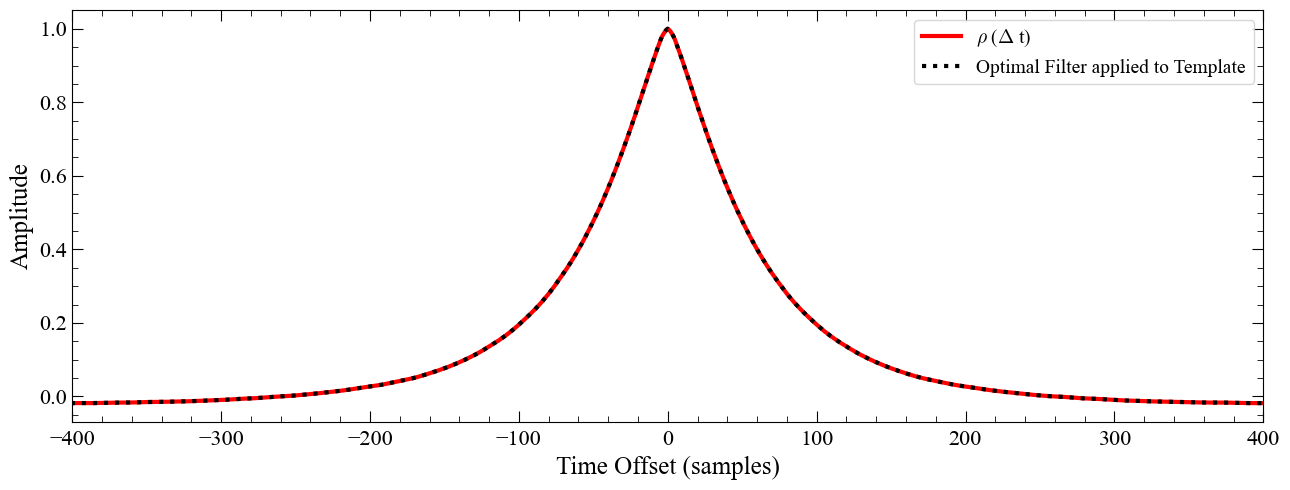

In [9]:
waveform_test = np.zeros(3 * len(templates_td))
waveform_test[len(templates_td):2*len(templates_td)] = templates_td
oftrigger_1x1.update_trace(waveform_test)
filtered_trace = oftrigger_1x1.get_filtered_trace()[0]
i_max = np.argmax(filtered_trace)

fig, ax = plt.subplots(1, 1, figsize=(13, 5))
ax.plot(delta_t_arr, rho_arr, label=r'$\rho$ ($\Delta$ t)', color='r', lw=3)
ax.plot(delta_t_arr, filtered_trace[i_max - 1000 : i_max + 1001], label='Optimal Filter applied to Template', color='k', linestyle=':', lw=3)
ax.set_xlabel('Time Offset (samples)')
ax.set_ylabel('Amplitude')
ax.legend(fontsize=14)
ax.set_xlim([-400, 400])
fig.tight_layout()
fig.show()


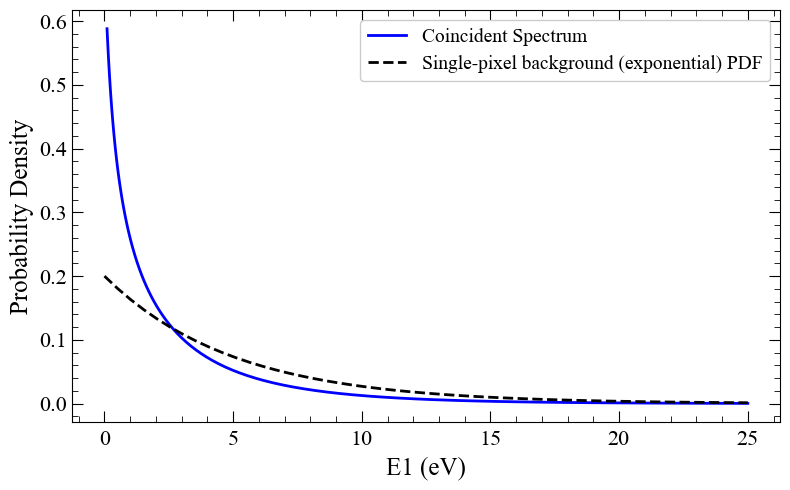

In [10]:
# Calculate the coincident spectrum of E1, given E0

rate_Hz = 10.

E1_eV_arr = np.geomspace(0.1, 25, 100)
E1_PDF_arr = np.zeros_like(E1_eV_arr)

for i, E1_obs in enumerate(E1_eV_arr):
    for delta_t_samples in range(-200, 200):
        
        delta_t = delta_t_samples / fs
        rho = oftrigger_1x1._of_base.calc_rho('MyTrigger', delta_t_samples)[0,0]
        pdf_delta_t = rate_Hz * np.exp(-1 * rate_Hz  * abs(delta_t)) / 2
        
        E1_real = E1_obs / max(0.001, rho)
        pdf_E1_real = lambda_E * np.exp(-1 * E1_real * lambda_E)
        
        E1_PDF_arr[i] += pdf_delta_t * pdf_E1_real
    
fig, ax = plt.subplots(1, 1, figsize=(8, 5))

integral = np.trapz(E1_PDF_arr, E1_eV_arr)
ax.plot(E1_eV_arr, E1_PDF_arr / integral, 'b', label='Coincident Spectrum')
ax.plot(np.linspace(0, 25), lambda_E * np.exp(-lambda_E * np.linspace(0, 25)), 'k--', label='Single-pixel background (exponential) PDF', lw=2)

#ax.set_xscale('log')
#ax.set_yscale('log')
ax.set_xlabel('E1 (eV)')
ax.set_ylabel('Probability Density')
ax.legend(framealpha=1., fontsize=14)
fig.tight_layout()
fig.show()

Coincident Rate: 4.91e-01 Hz, Single-pixel Rate: 99.60 Hz, Ratio: 4.93e-03


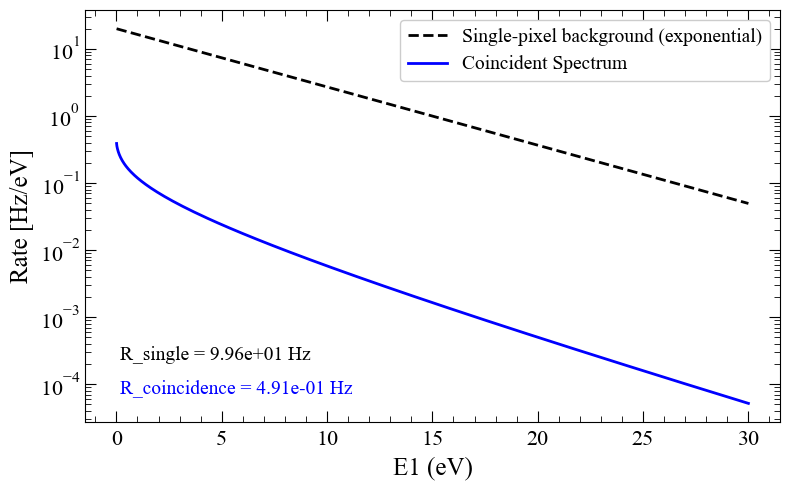

In [11]:
# When you decrease the single-pixel rate (rate_Hz), the coincident rate decreases much faster than the single-pixel rate.
# This is because coincidences require two independent random events (one in each pixel) to occur within a short coincidence window.
# 
# The probability of a coincidence is roughly proportional to the product of the rates in each pixel and the coincidence window width:
#     R_coinc ≈ rate_Hz^2 * Δt_window
# 
# In contrast, the single-pixel rate is just:
#     R_single ≈ rate_Hz
# 
# Therefore, the ratio:
#     R_coinc / R_single ≈ rate_Hz * Δt_window
# 
# As you decrease rate_Hz, this ratio decreases linearly with rate_Hz.
# This is why the coincident rate falls off much faster than the single-pixel rate as you lower the rate.

rate_Hz = 100.

E1_eV_arr = np.geomspace(0.01, 30, 150)
E1_dRdE_arr = np.zeros_like(E1_eV_arr)

delta_t_samples_arr = np.arange(-300, 300)
delta_t_s_arr = delta_t_samples_arr / fs

def process_E1_obs(args):
    E1_obs, delta_t_samples_arr, delta_t_s_arr, rate_Hz, lambda_E, oftrigger_1x1 = args
    result = 0.0
    
    for j, (delta_t_samples, delta_t_s) in enumerate(zip(delta_t_samples_arr, delta_t_s_arr)):
        rho = oftrigger_1x1._of_base.calc_rho('MyTrigger', delta_t_samples)[0,0]
        
        pdf_delta_t_Hz = rate_Hz * np.exp(-1 * rate_Hz * abs(delta_t_s)) / 2
        
        E1_real = E1_obs / max(0.001, rho)
        dRdE_bkgd_Hz_per_eV = rate_Hz * lambda_E * np.exp(-1 * E1_real * lambda_E)
        
        result += pdf_delta_t_Hz * dRdE_bkgd_Hz_per_eV * np.diff(delta_t_s_arr)[min(j - 1, 0)]
    
    return E1_obs, result

# Prepare arguments for each E1_obs value
args_list = [(E1_obs, delta_t_samples_arr, delta_t_s_arr, rate_Hz, lambda_E, oftrigger_1x1) 
             for E1_obs in E1_eV_arr]

# Create a process pool with max 4 CPUs and map the function
with Pool(processes=6) as pool:
    results = pool.map(process_E1_obs, args_list)

# Sort results by E1_obs and extract values
results.sort(key=lambda x: x[0])
E1_dRdE_arr = np.array([r[1] for r in results])
        
fig, ax = plt.subplots(1, 1, figsize=(8, 5))

ax.plot(E1_eV_arr, rate_Hz * lambda_E * np.exp(-lambda_E * E1_eV_arr), 'k--', label='Single-pixel background (exponential)', lw=2)
ax.plot(E1_eV_arr, E1_dRdE_arr, 'b-', label='Coincident Spectrum')

R_coincident = np.trapz(E1_dRdE_arr, E1_eV_arr)
R_single = np.trapz(rate_Hz * lambda_E * np.exp(-lambda_E * E1_eV_arr), E1_eV_arr)
ax.text(0.05, 0.15, f'R_single = {R_single:.2e} Hz', transform=ax.transAxes, fontsize=14)
ax.text(0.05, 0.07, f'R_coincidence = {R_coincident:.2e} Hz', transform=ax.transAxes, fontsize=14, color='b')

#R_coinc = {R_coincident:.2e} Hz\n
print(f'Coincident Rate: {R_coincident:.2e} Hz, Single-pixel Rate: {R_single:.2f} Hz, Ratio: {R_coincident / R_single:.2e}')

#ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('E1 (eV)')
ax.set_ylabel('Rate [Hz/eV]')
ax.legend(framealpha=1., fontsize=14)
fig.tight_layout()
fig.show()

### LEE Coincidence

In [20]:
from scipy.interpolate import interp1d
def run57_lee_bkgd():
    fin = 'Run57_LEE_templates/combined_spectra_shared57.txt'
    template = np.loadtxt(fin,skiprows=1)
    interp_func = interp1d(template[:,0],template[:,1],
                            bounds_error=False,
                            #fill_value='extrapolate',
                            fill_value=0.,
                            assume_sorted=True)

    return lambda x: (interp_func(x) / 86400.)

Run57 LEE Background: 1.08e+01 Hz


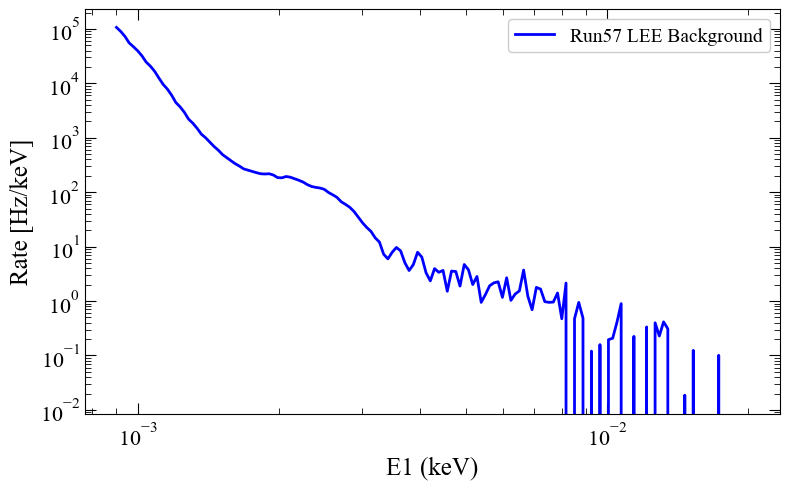

In [22]:
E1_keV_arr = np.geomspace(0.9, 20, 150) * 1e-3
fun = run57_lee_bkgd()
E1_dRdE_arr = np.array([fun(E) for E in E1_keV_arr])

fig, ax = plt.subplots(1, 1, figsize=(8, 5))
ax.plot(E1_keV_arr, E1_dRdE_arr, 'b-', label='Run57 LEE Background', lw=2)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('E1 (keV)')
ax.set_ylabel('Rate [Hz/keV]')
ax.legend(framealpha=1., fontsize=14)
fig.tight_layout()
fig.show()

print(f'Run57 LEE Background: {np.trapz(E1_dRdE_arr, E1_keV_arr):.2e} Hz')

Single-pixel Rate: 1.08e+01 Hz
Coincident Rate: 9.27e-04 Hz, Single-pixel Rate: 10.77 Hz, Ratio: 8.61e-05


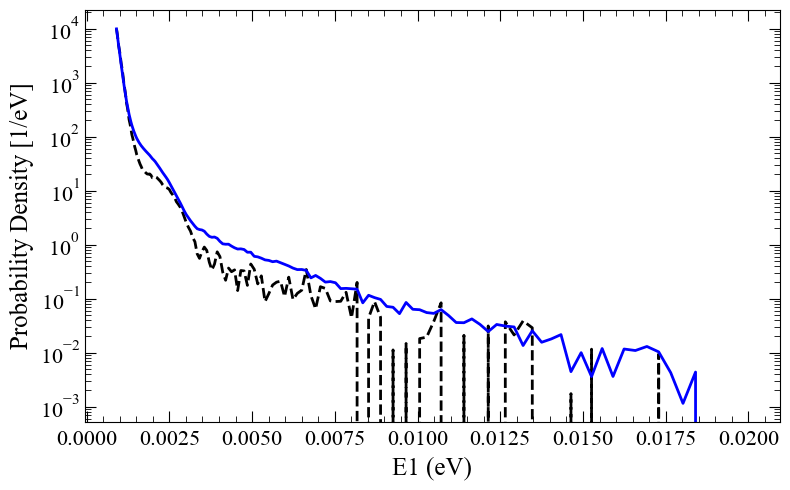

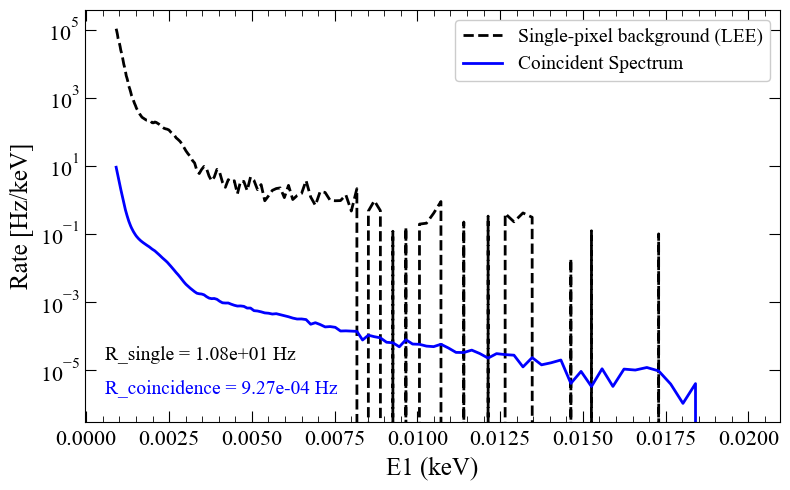

In [28]:
fun = run57_lee_bkgd()

E1_keV_arr = np.geomspace(0.9, 20, 150) * 1e-3
E1_dRdE_arr = np.zeros_like(E1_keV_arr)
E1_dRdE_single_arr = np.zeros_like(E1_keV_arr)

# Calculate the single-pixel background spectrum
for i, E in enumerate(E1_keV_arr):
    E1_dRdE_single_arr[i] = fun(E)

rate_Hz = np.trapz(E1_dRdE_single_arr, E1_keV_arr)
print(f'Single-pixel Rate: {rate_Hz:.2e} Hz')

delta_t_samples_arr = np.arange(-300, 300)
delta_t_s_arr = delta_t_samples_arr / fs

def process_E1_obs(args):
    E1_obs, delta_t_samples_arr, delta_t_s_arr, rate_Hz, lambda_E, oftrigger_1x1 = args
    result = 0.0
    
    for j, (delta_t_samples, delta_t_s) in enumerate(zip(delta_t_samples_arr, delta_t_s_arr)):
        rho = oftrigger_1x1._of_base.calc_rho('MyTrigger', delta_t_samples)[0,0]
        
        pdf_delta_t_Hz = rate_Hz * np.exp(-1 * rate_Hz * abs(delta_t_s)) / 2
        
        E1_real = E1_obs / max(0.001, rho)
        dRdE_bkgd_Hz_per_eV = fun(E1_real)
        
        result += pdf_delta_t_Hz * dRdE_bkgd_Hz_per_eV * np.diff(delta_t_s_arr)[min(j - 1, 0)]
    
    return E1_obs, result

# Prepare arguments for each E1_obs value
args_list = [(E1_obs, delta_t_samples_arr, delta_t_s_arr, rate_Hz, lambda_E, oftrigger_1x1) 
             for E1_obs in E1_keV_arr]

# Create a process pool with max 4 CPUs and map the function
with Pool(processes=6) as pool:
    results = pool.map(process_E1_obs, args_list)

# Sort results by E1_obs and extract values
results.sort(key=lambda x: x[0])
E1_dRdE_arr = np.array([r[1] for r in results])

##################

fig, ax = plt.subplots(1, 1, figsize=(8, 5))

integral = np.trapz(E1_dRdE_single_arr, E1_keV_arr)
ax.plot(E1_keV_arr, E1_dRdE_single_arr / integral, 'k--', label='Single-pixel background (LEE)', lw=2)
integral = np.trapz(E1_dRdE_arr, E1_keV_arr)
ax.plot(E1_keV_arr, E1_dRdE_arr / integral, 'b-', label='Coincident Spectrum')

ax.set_yscale('log')
ax.set_xlabel('E1 (eV)')
ax.set_ylabel('Probability Density [1/eV]')
fig.tight_layout()
fig.show()


fig, ax = plt.subplots(1, 1, figsize=(8, 5))

ax.plot(E1_keV_arr, E1_dRdE_single_arr, 'k--', label='Single-pixel background (LEE)', lw=2)
ax.plot(E1_keV_arr, E1_dRdE_arr, 'b-', label='Coincident Spectrum')

R_coincident = np.trapz(E1_dRdE_arr, E1_keV_arr)
R_single = np.trapz(E1_dRdE_single_arr, E1_keV_arr)
ax.text(0.03, 0.15, f'R_single = {R_single:.2e} Hz', transform=ax.transAxes, fontsize=14)
ax.text(0.03, 0.07, f'R_coincidence = {R_coincident:.2e} Hz', transform=ax.transAxes, fontsize=14, color='b')

#R_coinc = {R_coincident:.2e} Hz\n
print(f'Coincident Rate: {R_coincident:.2e} Hz, Single-pixel Rate: {R_single:.2f} Hz, Ratio: {R_coincident / R_single:.2e}')

#ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('E1 (keV)')
ax.set_ylabel('Rate [Hz/keV]')
ax.legend(framealpha=1., fontsize=14)
fig.tight_layout()
fig.show()

In [12]:
# Simulate noise data in two pixels
sim_trace_length = 1_250_000 * 10 # 30 seconds of data

sim_trace_length_s = sim_trace_length / fs # Convert to seconds
n_traces = int(sim_trace_length / f_frequencies)

# Simulate first pixel
simulated_waveform_pix0 = qetpy.gen_noise(csd, 1.25e6, n_traces)
simulated_waveform_pix0_td = np.zeros((n_channels, f_frequencies * n_traces))
for trace_i in range(n_traces):
    simulated_waveform_pix0_td[:, (trace_i * f_frequencies) : ((trace_i+1) * f_frequencies)] = simulated_waveform_pix0[trace_i, :]

# Simulate second pixel
simulated_waveform_pix1 = qetpy.gen_noise(csd, 1.25e6, n_traces)
simulated_waveform_pix1_td = np.zeros((n_channels, f_frequencies * n_traces))
for trace_i in range(n_traces):
    simulated_waveform_pix1_td[:, (trace_i * f_frequencies) : ((trace_i+1) * f_frequencies)] = simulated_waveform_pix1[trace_i, :]


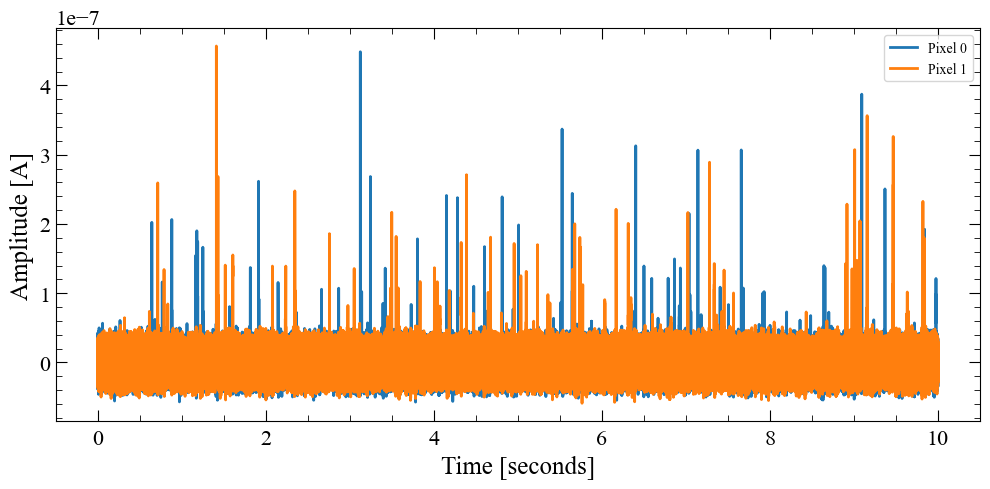

In [13]:
# Simulate pulses in the two pixels, assuming an exponential amplitude spectrum
# and Poisson distributed arrival times

# Number of expected events
expected_events = int(rate_Hz * sim_trace_length_s * 1.5)  # overestimate to be safe

###############

# Simulate arrival times in pixel 0
interarrival_times_s = np.random.exponential(1.0 / rate_Hz, expected_events)
arrival_times_s = np.cumsum(interarrival_times_s)
arrival_times = arrival_times_s * fs  # Convert to samples
arrival_times = arrival_times.astype(int)  # Convert to integer samples
arrival_times_true_pix0 = arrival_times[arrival_times < (sim_trace_length - f_frequencies)]  # Truncate to stay within total duration

# Simulate energies in pixel 0
energies_eV_true_pix0 = np.random.exponential(1.0 / lambda_E, len(arrival_times_true_pix0))

# Add pulses to the simulated waveform in pixel 0
for i, arrival_time in enumerate(arrival_times_true_pix0):
    simulated_waveform_pix0_td[0, arrival_time:arrival_time + f_frequencies] += energies_eV_true_pix0[i] * templates_td

###############

# Simulate arrival times in pixel 1
interarrival_times_s = np.random.exponential(1.0 / rate_Hz, expected_events)
arrival_times_s = np.cumsum(interarrival_times_s)
arrival_times = arrival_times_s * fs  # Convert to samples
arrival_times = arrival_times.astype(int)  # Convert to integer samples
arrival_times_true_pix1 = arrival_times[arrival_times < (sim_trace_length - f_frequencies)]  # Truncate to stay within total duration

# Simulate energies in pixel 0
energies_eV_true_pix1 = np.random.exponential(1.0 / lambda_E, len(arrival_times_true_pix1))

# Add pulses to the simulated waveform in pixel 0
for i, arrival_time in enumerate(arrival_times_true_pix1):
    simulated_waveform_pix1_td[0, arrival_time:arrival_time + f_frequencies] += energies_eV_true_pix1[i] * templates_td

# Plot the simulated waveforms for both pixels
fig, ax = plt.subplots(1, 1, figsize=(10, 5))

# Display 10 seconds of real data
t_sec = np.arange(simulated_waveform_pix0_td.shape[-1]) * 0.8e-6
ax.plot(t_sec, simulated_waveform_pix0_td[0], label='Pixel 0')
ax.plot(t_sec, simulated_waveform_pix1_td[0], label='Pixel 1')
ax.set_xlabel('Time [seconds]')
ax.set_ylabel('Amplitude [A]')
ax.legend(loc='best')

fig.tight_layout()
fig.show()

In [14]:
# Convert waveform, template, and CSD into OF format
simulated_waveform_td = np.concatenate([simulated_waveform_pix0_td, simulated_waveform_pix1_td])

template_OF = np.zeros((2, 2, f_frequencies))
template_OF[0, 0, :] = templates_td
template_OF[1, 1, :] = templates_td

csd_OF = np.zeros((2, 2, f_frequencies))
csd_OF[0, 0, :] = csd
csd_OF[1, 1, :] = csd

In [15]:
# Process the data
oftrigger = detprocess.OptimumFilterTrigger('MyTrigger0|MyTrigger1', fs, template_OF, csd_OF, pretrigger_samples=int(f_frequencies/2), )

# Run OF Trigger
oftrigger.update_trace(simulated_waveform_td)
oftrigger.find_triggers(4, pileup_window_msec=2.)

# Print trigger results
trigger_indices = oftrigger.get_trigger_data()['MyTrigger0|MyTrigger1']['trigger_index']
E0_arr = oftrigger.get_trigger_data()['MyTrigger0|MyTrigger1']['trigger_amplitude_0']
E1_arr = oftrigger.get_trigger_data()['MyTrigger0|MyTrigger1']['trigger_amplitude_1']
n_triggers = len(trigger_indices)
print(f'Found {n_triggers} triggers in the simulated data.')
#for i, trigger_index in enumerate(trigger_indices):
#    print(f'Trigger {i} at sample {trigger_index}, time = {trigger_index * 0.8e-6:.4f} seconds')

# Plot a few triggered events
for i in range(n_triggers):

    if E0_arr[i] < 10 or E1_arr[i] < 10:
        continue # Skip low-energy triggers

    print(f'Trigger {i}: E0 = {E0_arr[i]:.3f} eV, E1 = {E1_arr[i]:.3f} eV')
    
    # Determine trigger time
    trigger_time_samples = trigger_indices[i]
    trigger_time_ms = trigger_time_samples * 0.8e-3

    # Load trace in the vicinity of the trigger
    t_min_samples = trigger_time_samples - 12500
    t_max_samples = trigger_time_samples + 12500
    trace0 = simulated_waveform_td[0][t_min_samples:t_max_samples]
    trace1 = simulated_waveform_td[1][t_min_samples:t_max_samples]
    trace0 = trace0 - np.median(trace0)
    trace1 = trace1 - np.median(trace1)
    t_ms = np.arange(t_min_samples, t_max_samples) * 0.8e-3

    # Two options for plotting (toggle with plot_lpf below):
    #    Plot raw trace
    #    Plot trace after 50 kHz low-pass filter
    plot_lpf = True
    fig, ax = plt.subplots(1, 1, figsize=(10, 5))
    
    if plot_lpf:
        ax.plot(t_ms, qetpy.utils.lowpassfilter(trace0, cut_off_freq=50e3, fs=1.25e6), label='Channel 0 (LPF, 50 kHz)')
        ax.plot(t_ms, qetpy.utils.lowpassfilter(trace1, cut_off_freq=50e3, fs=1.25e6), label='Channel 1 (LPF, 50 kHz)')
    else:
        ax.plot(t_ms, trace0)
        ax.plot(t_ms, trace1)

    ymin, ymax = ax.get_ylim()
    ax.plot([trigger_time_ms, trigger_time_ms], [ymin, ymax], 'k--', lw=2, label='Trigger')
    ax.set_ylim([ymin, ymax])
    
    ax.set_xlabel('Time [ms]')
    ax.set_ylabel('TES Current [A]')
    ax.legend(loc='best', fontsize=14)
    fig.tight_layout()
    fig.show()


Found 289 triggers in the simulated data.


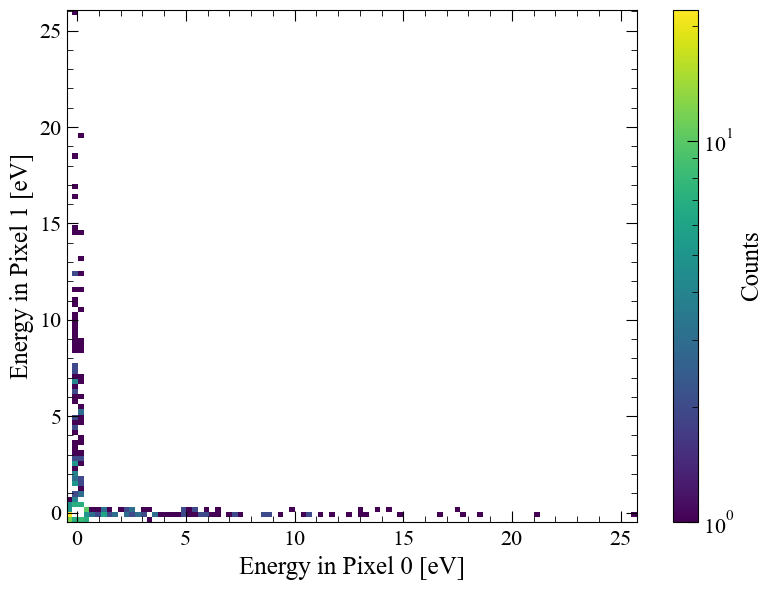

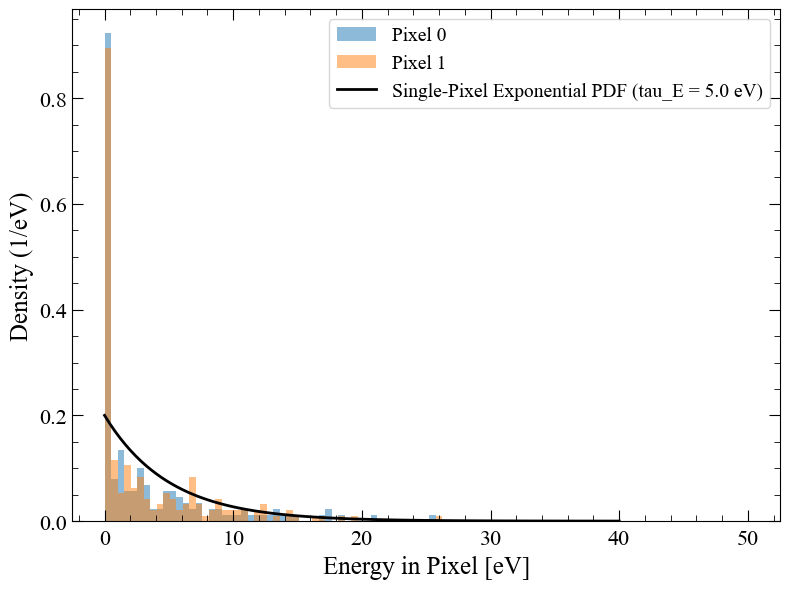

In [16]:
E0_arr = np.array(E0_arr)
E1_arr = np.array(E1_arr)

fig, ax = plt.subplots(1, 1, figsize=(8, 6))

h = ax.hist2d(E0_arr, E1_arr,
           bins=(100, 100), norm=mpl.colors.LogNorm(), cmap='viridis', cmin=1)
fig.colorbar(h[3], ax=ax, label='Counts')

ax.set_xlabel('Energy in Pixel 0 [eV]')
ax.set_ylabel('Energy in Pixel 1 [eV]')
fig.tight_layout()
fig.show()

########
fig, ax = plt.subplots(1, 1, figsize=(8, 6))

ax.hist(E0_arr, np.linspace(0., 50, 100), density=True, alpha=0.5, label='Pixel 0')
ax.hist(E1_arr, np.linspace(0., 50, 100), density=True, alpha=0.5, label='Pixel 1')
ax.set_xlabel('Energy in Pixel [eV]')
ax.set_ylabel('Density (1/eV)')
lambda_E_test = 1 / 5.
ax.plot(np.linspace(0., 40, 100), lambda_E_test * np.exp(-lambda_E_test * np.linspace(0., 40, 100)), color='k', label=f'Single-Pixel Exponential PDF (tau_E = {1/lambda_E_test} eV)', lw=2)
ax.legend(loc='best', fontsize=14)

fig.tight_layout()
fig.show()
